# 第2章 Notebook：形態比較と放熱効率

対応章: [`../chapters/02_stegosaurus_heat_shape.md`](../chapters/02_stegosaurus_heat_shape.md)

この notebook は、卒業研究準備セミナーの数値実験用である。上から順に実行すれば、本文で説明した図を再現できる。設定パラメータは上部のセルにまとめてある。乱数は seed を固定している。

## 1. ライブラリ読み込みと共通パラメータ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

np.random.seed(0)

k = 20.0; T_b = 40.0; T_air = 25.0
theta_b = T_b - T_air
L = 0.40           # common height [m]
V_target = 2.0e-3  # common volume [m^3]
h0 = 25.0          # reference convection coefficient
kinds = ['cone_spike', 'flat_spike', 'tri_plate', 'ellip_plate']

## 2. 形状の幾何量（簡略化したフィン近似）

各形状を「断面積 $A_c$・周長 $P$・体積 $V$・表面積 $A$」を持つフィンとみなす。体積係数 cV は、尖った形状で 1/3、板状で 1/2 とする（簡略化）。

In [2]:
def shape_geom(kind, s, L):
    if kind == 'cone_spike':
        r = s; Ac = np.pi * r**2; P = 2 * np.pi * r; cV = 1/3
    elif kind == 'flat_spike':
        a = s; b = 0.30 * s; Ac = np.pi * a * b
        P = np.pi * (3*(a+b) - np.sqrt((3*a+b)*(a+3*b))); cV = 1/3
    elif kind == 'tri_plate':
        w = 2.0 * s; t = 0.15 * s; Ac = w * t; P = 2*(w+t); cV = 0.5
    elif kind == 'ellip_plate':
        a = 1.2 * s; b = 0.12 * s; Ac = np.pi * a * b
        P = np.pi * (3*(a+b) - np.sqrt((3*a+b)*(a+3*b))); cV = 0.5
    else:
        raise ValueError(kind)
    V = cV * Ac * L
    A = P * L            # lateral surface (simplified, prism-like)
    return Ac, P, V, A

def fin_Q(Ac, P, L, h):
    m = np.sqrt(h * P / (k * Ac))
    return np.sqrt(h * P * k * Ac) * theta_b * np.tanh(m * L)

def scale_to_volume(kind, L, V_target):
    _, _, V0, _ = shape_geom(kind, 1.0, L)
    return np.sqrt(V_target / V0)   # V ~ s^2

## 3. 形状内部の温度場を解く2次元モデル

上のフィン近似は形状を数個の幾何量に縮約するため、形状のどこが温かいかは見えない。ここでは各形状を厚さ一定の薄い板として格子上に描き、根元を体温 $T_b$ に固定する。前面・背面と輪郭から外気へ対流放熱する定常熱伝導を有限体積法で解く。

比較条件は **同じ高さ・厚さ・材料・根元温度・外気温・対流係数** とする。これは教育用の2次元断面モデルであり、厳密な3次元形状や血管分布を再現するものではない。

In [3]:
# --- 2D thin-plate settings ---
thickness_2d = 0.020  # plate thickness [m]
dx_2d = 0.005         # square-cell size [m]
x2 = np.arange(-0.25, 0.25 + dx_2d / 2, dx_2d)
y2 = np.arange(0.0, L + dx_2d / 2, dx_2d)
X2, Y2 = np.meshgrid(x2, y2)

shape_labels = {
    'cone_spike': 'cone spike',
    'flat_spike': 'flat spike',
    'tri_plate': 'triangular plate',
    'ellip_plate': 'elliptic plate',
}

def shape_mask_2d(kind):
    eta = np.clip(Y2 / L, 0.0, 1.0)
    if kind == 'cone_spike':
        half_width = 0.055 * (1.0 - eta) ** 1.5 + dx_2d / 2
    elif kind == 'flat_spike':
        half_width = 0.100 * (1.0 - eta) ** 1.1 + dx_2d / 2
    elif kind == 'tri_plate':
        half_width = 0.180 * (1.0 - eta) + dx_2d / 2
    elif kind == 'ellip_plate':
        half_width = 0.180 * np.sqrt(np.clip(1.0 - ((eta - 0.5) / 0.5) ** 2, 0.0, None))
        half_width = np.maximum(half_width, 0.020 * (1.0 - eta) + dx_2d / 2)
    else:
        raise ValueError(kind)
    mask = np.abs(X2) <= half_width
    # All shapes have a short root connected to the body-temperature boundary.
    mask |= (Y2 <= 2 * dx_2d) & (np.abs(X2) <= 0.025)
    return mask

def solve_shape_temperature(mask, h=h0):
    index = -np.ones(mask.shape, dtype=int)
    index[mask] = np.arange(mask.sum())
    A = lil_matrix((mask.sum(), mask.sum()))
    b = np.zeros(mask.sum())
    base = mask & (Y2 <= dx_2d / 2)
    g_cond = k * thickness_2d
    g_face = 2.0 * h * dx_2d**2
    g_edge = h * thickness_2d * dx_2d
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for iy, ix in zip(*np.where(mask)):
        p = index[iy, ix]
        if base[iy, ix]:
            A[p, p] = 1.0
            b[p] = T_b
            continue

        diagonal = g_face
        exposed_edges = 0
        for diy, dix in directions:
            jy, jx = iy + diy, ix + dix
            inside_grid = 0 <= jy < mask.shape[0] and 0 <= jx < mask.shape[1]
            if inside_grid and mask[jy, jx]:
                diagonal += g_cond
                if base[jy, jx]:
                    b[p] += g_cond * T_b
                else:
                    A[p, index[jy, jx]] = -g_cond
            else:
                # The lower root is attached to the body, not exposed to air.
                if not (diy == -1 and iy == 0):
                    exposed_edges += 1

        diagonal += exposed_edges * g_edge
        A[p, p] = diagonal
        b[p] += (g_face + exposed_edges * g_edge) * T_air

    values = spsolve(A.tocsr(), b)
    temperature = np.full(mask.shape, np.nan)
    temperature[mask] = values

    # Convective heat loss from front/back faces and exposed outline.
    q_face = np.nansum(2.0 * h * (temperature - T_air) * dx_2d**2)
    q_edge = 0.0
    for iy, ix in zip(*np.where(mask)):
        for diy, dix in directions:
            jy, jx = iy + diy, ix + dix
            inside_grid = 0 <= jy < mask.shape[0] and 0 <= jx < mask.shape[1]
            if not (inside_grid and mask[jy, jx]) and not (diy == -1 and iy == 0):
                q_edge += h * thickness_2d * dx_2d * (temperature[iy, ix] - T_air)

    warm_threshold = T_air + 0.5 * (T_b - T_air)
    return {
        'mask': mask,
        'temperature': temperature,
        'local_face_flux': 2.0 * h * (temperature - T_air),
        'Q_2D': q_face + q_edge,
        'mean_temperature': np.nanmean(temperature),
        'warm_fraction': np.mean(values >= warm_threshold),
    }

field_results = {kind: solve_shape_temperature(shape_mask_2d(kind)) for kind in kinds}
pd.DataFrame([
    [shape_labels[kind], result['Q_2D'], result['mean_temperature'], result['warm_fraction']]
    for kind, result in field_results.items()
], columns=['shape', 'Q_2D [W]', 'mean T [degC]', 'warm area fraction'])

,shape,Q_2D [W],mean T [degC],warm area fraction
0,cone spike,7.570464,30.961589,0.339218
1,flat spike,13.307526,30.621111,0.312846
2,triangular plate,23.274923,30.604277,0.308308
3,elliptic plate,7.831896,26.211676,0.019261


## 4. 形状上の温度と局所放熱を可視化する

上段は形状内部の温度、下段は前面・背面から空気へ逃げる局所放熱密度 $q''=2h(T-T_{\mathrm{air}})$ である。すべての形状で同じカラースケールを使う。白線は等温線、各列のタイトルは輪郭からの放熱も含む総放熱量を示す。

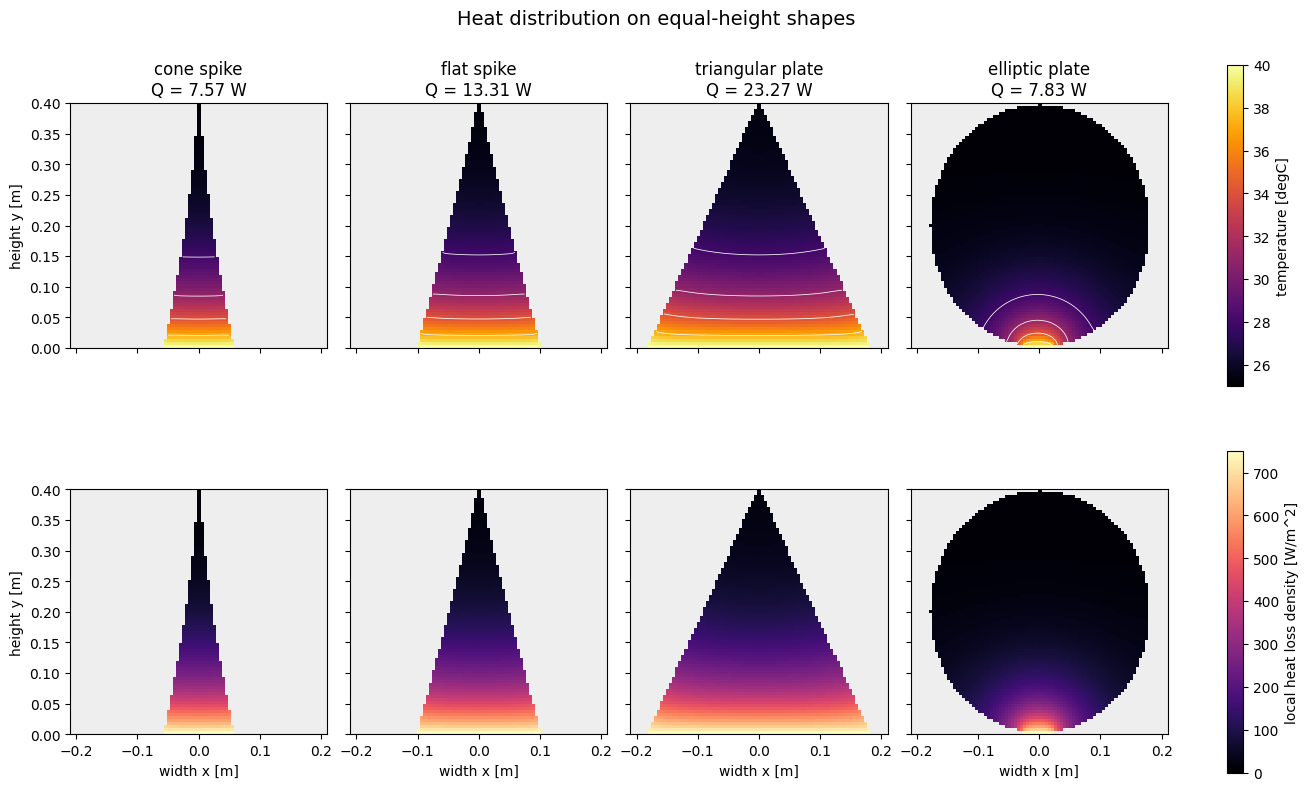

In [4]:
temperature_cmap = plt.colormaps['inferno'].copy()
flux_cmap = plt.colormaps['magma'].copy()
temperature_cmap.set_bad('#eeeeee')
flux_cmap.set_bad('#eeeeee')

fig, axes = plt.subplots(2, len(kinds), figsize=(13, 8), sharex=True, sharey=True, constrained_layout=True)
for col, kind in enumerate(kinds):
    result = field_results[kind]
    temperature = result['temperature']
    flux = result['local_face_flux']
    im_t = axes[0, col].imshow(
        temperature, origin='lower', extent=[x2.min(), x2.max(), y2.min(), y2.max()],
        vmin=T_air, vmax=T_b, cmap=temperature_cmap, aspect='equal'
    )
    axes[0, col].contour(X2, Y2, temperature, levels=[28, 31, 34, 37], colors='white', linewidths=0.55)
    im_q = axes[1, col].imshow(
        flux, origin='lower', extent=[x2.min(), x2.max(), y2.min(), y2.max()],
        vmin=0.0, vmax=2.0 * h0 * (T_b - T_air), cmap=flux_cmap, aspect='equal'
    )
    axes[0, col].set_title(f"{shape_labels[kind]}\nQ = {result['Q_2D']:.2f} W")
    axes[1, col].set_xlabel('width x [m]')
    for row in range(2):
        axes[row, col].set_xlim(-0.21, 0.21)
        axes[row, col].set_ylim(0.0, L)
axes[0, 0].set_ylabel('height y [m]')
axes[1, 0].set_ylabel('height y [m]')
fig.colorbar(im_t, ax=axes[0, :], label='temperature [degC]', shrink=0.85)
fig.colorbar(im_q, ax=axes[1, :], label='local heat loss density [W/m^2]', shrink=0.85)
fig.suptitle('Heat distribution on equal-height shapes', fontsize=14)
fig.savefig('../assets/figures/02_shape_temperature_fields.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. 同体積での比較表

In [5]:
rows = []
for kind in kinds:
    s = scale_to_volume(kind, L, V_target)
    Ac, P, V, A = shape_geom(kind, s, L)
    Q = fin_Q(Ac, P, L, h0)
    rows.append([kind, Q, V, A, Q / V, Q / A])
df = pd.DataFrame(rows, columns=['shape', 'Q', 'V', 'A', 'E_V', 'E_A'])
df

,shape,Q,V,A,E_V,E_A
0,cone_spike,26.630783,0.002,0.173664,13315.391591,153.346330
1,flat_spike,30.289782,0.002,0.221313,15144.890979,136.864182
2,tri_plate,29.697241,0.002,0.314028,14848.620394,94.568888
3,ellip_plate,28.520179,0.002,0.289781,14260.089390,98.419704


## 6. 体積あたり効率 E_V と表面積あたり効率 E_A の比較

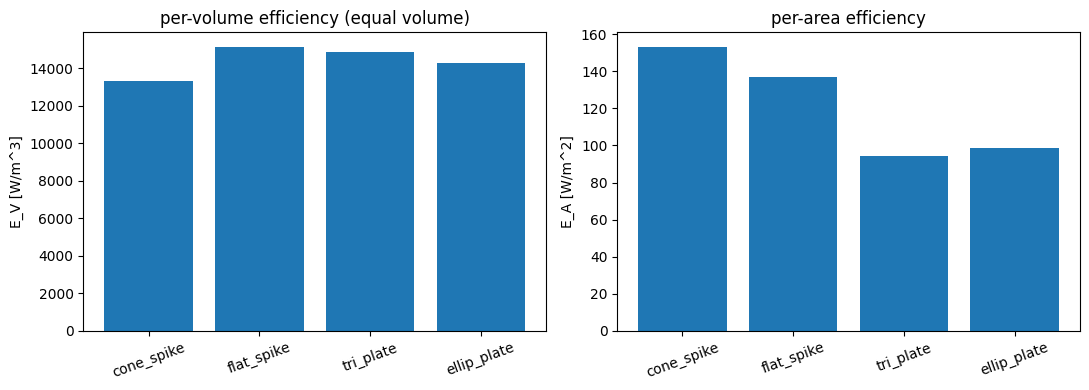

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(df['shape'], df['E_V']); ax[0].set_ylabel('E_V [W/m^3]')
ax[0].set_title('per-volume efficiency (equal volume)')
ax[0].tick_params(axis='x', rotation=20)
ax[1].bar(df['shape'], df['E_A']); ax[1].set_ylabel('E_A [W/m^2]')
ax[1].set_title('per-area efficiency')
ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

## 7. パラメータスイープ：風速（h）への感度

対流係数 h を変えたとき、各形状の体積あたり効率 E_V の順位が入れ替わるかを見る。

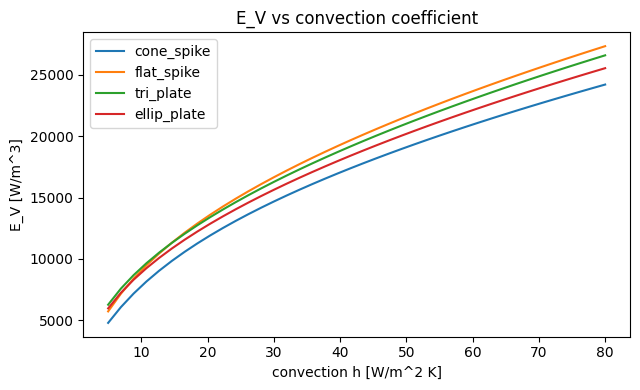

In [7]:
hs = np.linspace(5, 80, 40)
plt.figure(figsize=(6.5, 4))
for kind in kinds:
    s = scale_to_volume(kind, L, V_target)
    Ac, P, V, A = shape_geom(kind, s, L)
    Ev = np.array([fin_Q(Ac, P, L, h) / V for h in hs])
    plt.plot(hs, Ev, label=kind)
plt.xlabel('convection h [W/m^2 K]'); plt.ylabel('E_V [W/m^3]')
plt.title('E_V vs convection coefficient'); plt.legend()
plt.tight_layout(); plt.show()

## 8. 卒研でFEMに発展させる場合のメモ

ここでは 3D FEM ではなく、フィン近似で形状を比較した。卒研では同じ形状を `scikit-fem` などで 2D/3D 熱伝導として解き直し、近似がどこまで妥当かを検証できる。

## 9. 課題（自分で変更する）

1. `h0` を 2 倍にすると E_V の順位は変わるか、表を作り直して確かめよ。
2. 「同投影面積」で比較するよう正規化を変え、結論がどう変わるか調べよ。
3. 2次元温度場で `h0` または `thickness_2d` を変え、先端温度・総放熱量・温かい領域の割合がどう変わるか比較せよ。

In [8]:
# === 課題セル ===
for h0_try in [15.0, 30.0, 60.0]:
    order = sorted(kinds, key=lambda kd: -fin_Q(*shape_geom(kd, scale_to_volume(kd, L, V_target), L)[:2], L, h0_try)
                   / shape_geom(kd, scale_to_volume(kd, L, V_target), L)[2])
    print(f'h0={h0_try}: E_V ranking =', order)

h0=15.0: E_V ranking = ['flat_spike', 'tri_plate', 'ellip_plate', 'cone_spike']
h0=30.0: E_V ranking = ['flat_spike', 'tri_plate', 'ellip_plate', 'cone_spike']
h0=60.0: E_V ranking = ['flat_spike', 'tri_plate', 'ellip_plate', 'cone_spike']
